In [3]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from rembg import remove
from diffusers import StableDiffusionXLPipeline

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [4]:
device = "cpu"

torch.set_num_threads(12)
torch.set_num_interop_threads(12)
torch.backends.mkldnn.enabled = True

In [5]:
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float32,
    use_safetensors=True
).to(device)

pipe.enable_attention_slicing()
pipe.set_progress_bar_config(disable=False)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [6]:
CHARACTER_PROMPT = """
flat 2D animation style, simple cartoon girl,
short brown bob haircut,
yellow raincoat, blue rain boots,
back view, clean outlines, soft shading,
minimal detail, children's book illustration
"""

NEGATIVE_PROMPT = """
photorealistic, detailed face, freckles,
realistic lighting, 3D render
"""

  0%|          | 0/25 [00:00<?, ?it/s]

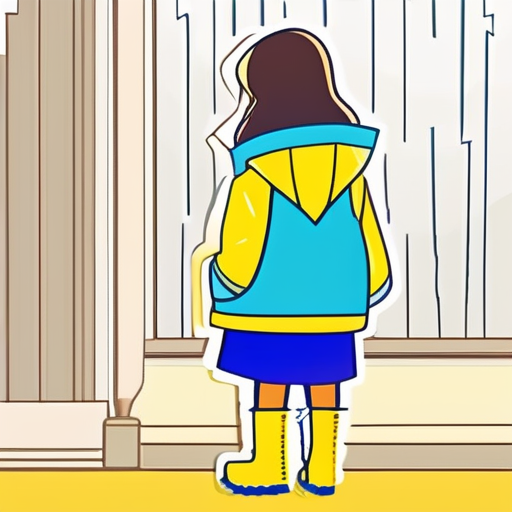

In [7]:
SEED = 42
WIDTH = 512
HEIGHT = 512

generator = torch.Generator(device).manual_seed(SEED)

master_character = pipe(
    prompt=CHARACTER_PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    width=WIDTH,
    height=HEIGHT,
    num_inference_steps=25,
    guidance_scale=6.5,
    generator=generator
).images[0]

display(master_character)

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

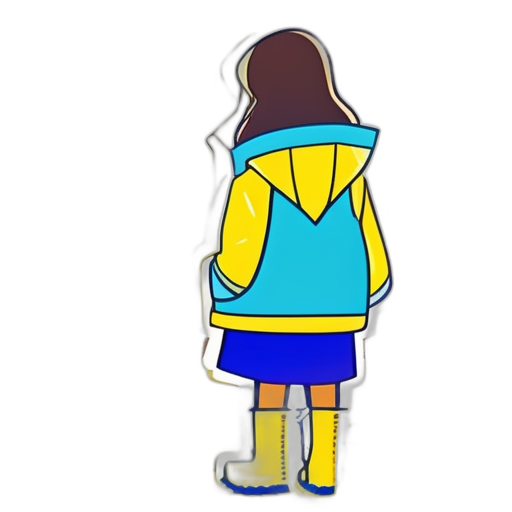

In [8]:
cutout = remove(master_character)
cutout = cutout.convert("RGBA")
display(cutout)

In [9]:
char_np = np.array(cutout)

In [10]:
def warp_image(img, angle=0, shift_x=0, shift_y=0, scale=1.0):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    M[0, 2] += shift_x
    M[1, 2] += shift_y
    warped = cv2.warpAffine(img, M, (w, h), borderValue=(0,0,0,0))
    return warped

In [11]:
pose1 = char_np
pose2 = warp_image(char_np, angle=-10, shift_y=20)
pose3 = warp_image(char_np, angle=8, shift_x=25)
pose4 = warp_image(char_np, shift_x=40)

In [12]:
def composite_white(fg):
    bg = Image.new("RGBA", (WIDTH, HEIGHT), (255, 255, 255, 255))
    fg = Image.fromarray(fg)
    return Image.alpha_composite(bg, fg)

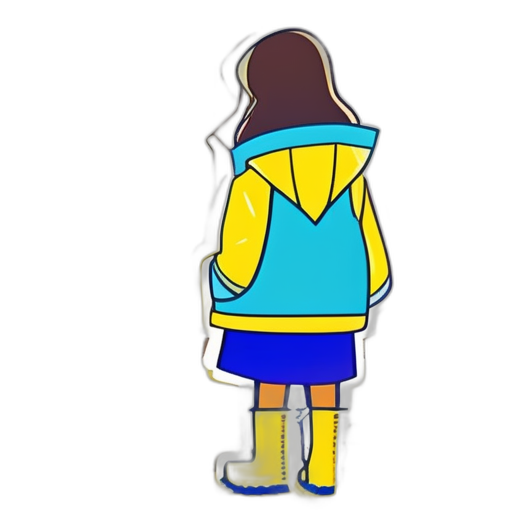

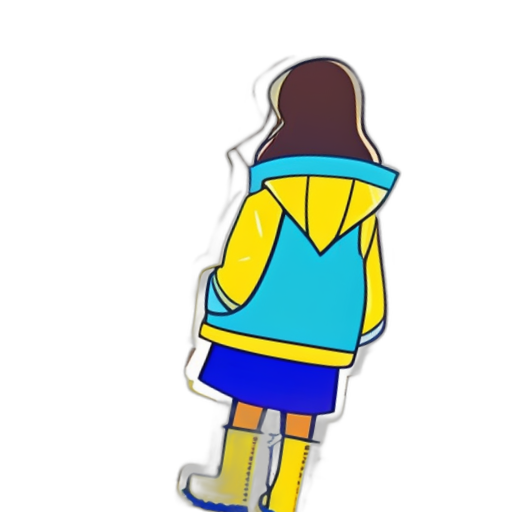

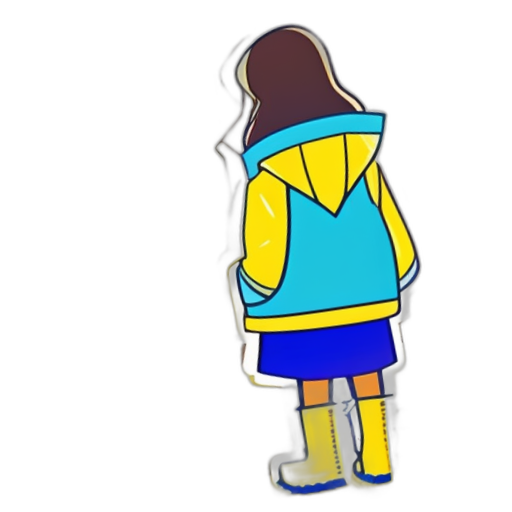

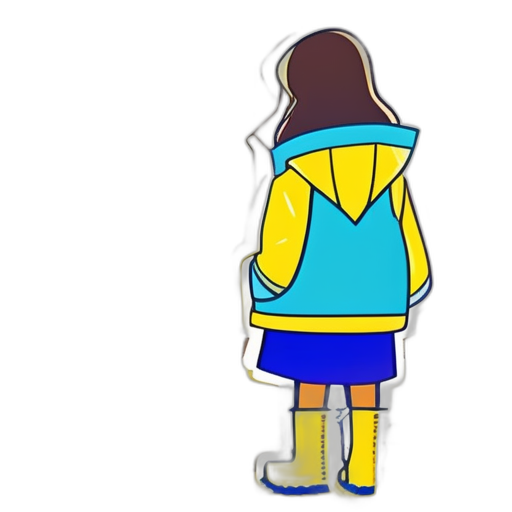

In [13]:
scene1 = composite_white(pose1)
scene2 = composite_white(pose2)
scene3 = composite_white(pose3)
scene4 = composite_white(pose4)

display(scene1)
display(scene2)
display(scene3)
display(scene4)

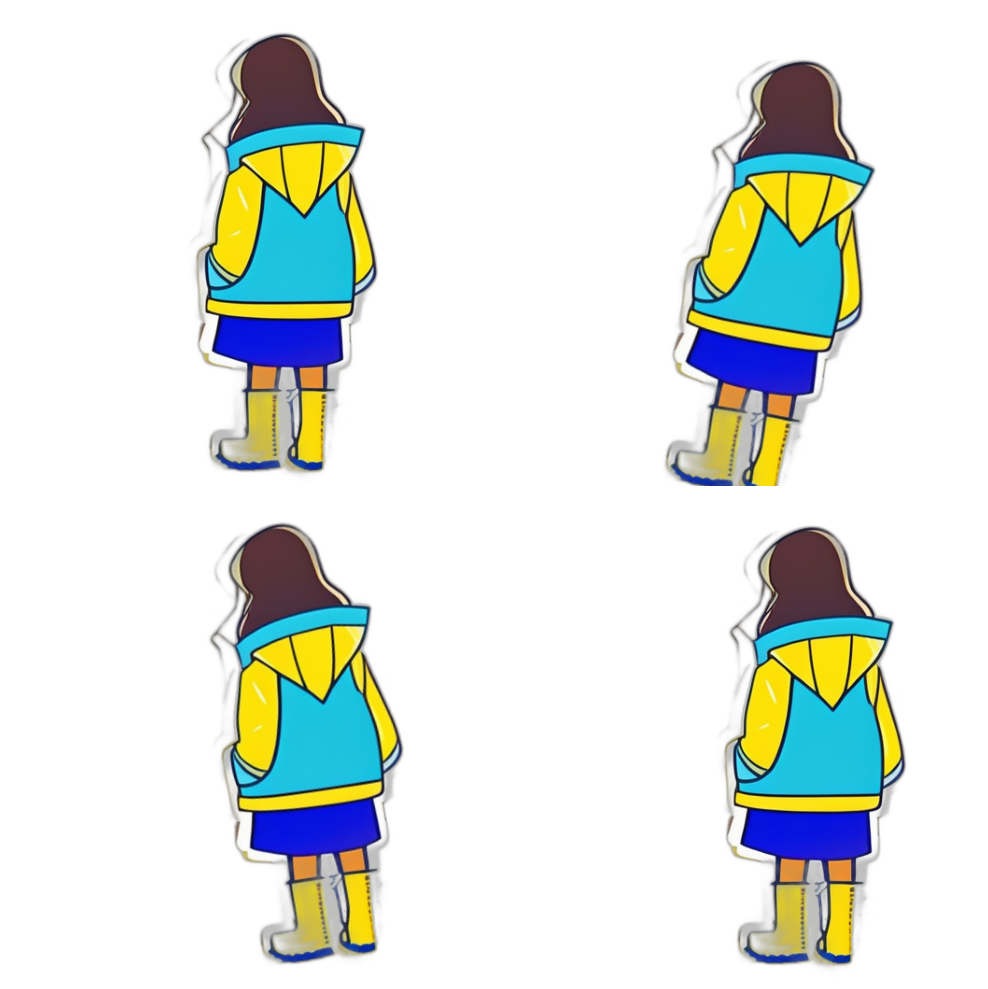

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(scene1)
axs[0, 1].imshow(scene2)
axs[1, 0].imshow(scene3)
axs[1, 1].imshow(scene4)

for ax in axs.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()